In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/datasnaek/youtube-new/GBvideos.csv
/kaggle/input/datasets/datasnaek/youtube-new/MXvideos.csv
/kaggle/input/datasets/datasnaek/youtube-new/KRvideos.csv
/kaggle/input/datasets/datasnaek/youtube-new/MX_category_id.json
/kaggle/input/datasets/datasnaek/youtube-new/GB_category_id.json
/kaggle/input/datasets/datasnaek/youtube-new/US_category_id.json
/kaggle/input/datasets/datasnaek/youtube-new/IN_category_id.json
/kaggle/input/datasets/datasnaek/youtube-new/DEvideos.csv
/kaggle/input/datasets/datasnaek/youtube-new/KR_category_id.json
/kaggle/input/datasets/datasnaek/youtube-new/RU_category_id.json
/kaggle/input/datasets/datasnaek/youtube-new/FRvideos.csv
/kaggle/input/datasets/datasnaek/youtube-new/USvideos.csv
/kaggle/input/datasets/datasnaek/youtube-new/INvideos.csv
/kaggle/input/datasets/datasnaek/youtube-new/RUvideos.csv
/kaggle/input/datasets/datasnaek/youtube-new/CA_category_id.json
/kaggle/input/datasets/datasnaek/youtube-new/DE_category_id.json
/kaggle/input/da

#### End-to-End Data Science Project (ML + NLP + Explainability)

# BUSINESS UNDERSTANDING

### 1. Business Understanding

###  Objective
Predict whether a YouTube video will stay trending for more than 3 days.

### Why This Problem?
Trending longevity reflects:
- Sustained engagement
- Algorithm reinforcement
- Content quality signals

### Analytical Goals
1. Identify engagement patterns
2. Extract textual signals (NLP)
3. Build predictive ML models
4. Explain model decisions
5. Test generalization across countries

Problem Type:
Binary Classification

# IMPORT LIBRARIES

In [2]:
# Data
import pandas as pd
import numpy as np

# Visualization
import plotly.express as px
import plotly.graph_objects as go

# ML
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# NLP
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Text cleaning
import re
import string

# WordCloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

# LOAD DATA

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print("Folder:", dirname)
    for filename in filenames:
        print("   ", filename)

Folder: /kaggle/input
Folder: /kaggle/input/datasets
Folder: /kaggle/input/datasets/datasnaek
Folder: /kaggle/input/datasets/datasnaek/youtube-new
    GBvideos.csv
    MXvideos.csv
    KRvideos.csv
    MX_category_id.json
    GB_category_id.json
    US_category_id.json
    IN_category_id.json
    DEvideos.csv
    KR_category_id.json
    RU_category_id.json
    FRvideos.csv
    USvideos.csv
    INvideos.csv
    RUvideos.csv
    CA_category_id.json
    DE_category_id.json
    JP_category_id.json
    JPvideos.csv
    FR_category_id.json
    CAvideos.csv


In [4]:
import pandas as pd
import glob

path = "/kaggle/input/datasets/datasnaek/youtube-new/"
files = glob.glob(path + "*videos.csv")

dfs = []

for file in files:
    country = file.split("/")[-1][:2]
    
    temp = pd.read_csv(
        file,
        encoding="utf-8",
        encoding_errors="replace"   
    )
    
    temp["country"] = country
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print("Shape:", df.shape)
df.head()

Shape: (375942, 17)


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country
0,Jw1Y-zhQURU,17.14.11,John Lewis Christmas Ad 2017 - #MozTheMonster,John Lewis,26,2017-11-10T07:38:29.000Z,"christmas|""john lewis christmas""|""john lewis""|...",7224515,55681,10247,9479,https://i.ytimg.com/vi/Jw1Y-zhQURU/default.jpg,False,False,False,Click here to continue the story and make your...,GB
1,3s1rvMFUweQ,17.14.11,Taylor Swift: …Ready for It? (Live) - SNL,Saturday Night Live,24,2017-11-12T06:24:44.000Z,"SNL|""Saturday Night Live""|""SNL Season 43""|""Epi...",1053632,25561,2294,2757,https://i.ytimg.com/vi/3s1rvMFUweQ/default.jpg,False,False,False,Musical guest Taylor Swift performs …Ready for...,GB
2,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787420,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. Beyoncé i...,GB
3,PUTEiSjKwJU,17.14.11,Goals from Salford City vs Class of 92 and Fri...,Salford City Football Club,17,2017-11-13T02:30:38.000Z,"Salford City FC|""Salford City""|""Salford""|""Clas...",27833,193,12,37,https://i.ytimg.com/vi/PUTEiSjKwJU/default.jpg,False,False,False,Salford drew 4-4 against the Class of 92 and F...,GB
4,rHwDegptbI4,17.14.11,Dashcam captures truck's near miss with child ...,Cute Girl Videos,25,2017-11-13T01:45:13.000Z,[none],9815,30,2,30,https://i.ytimg.com/vi/rHwDegptbI4/default.jpg,False,False,False,Dashcam captures truck's near miss with child ...,GB


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375942 entries, 0 to 375941
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   video_id                375942 non-null  object
 1   trending_date           375942 non-null  object
 2   title                   375942 non-null  object
 3   channel_title           375942 non-null  object
 4   category_id             375942 non-null  int64 
 5   publish_time            375942 non-null  object
 6   tags                    375942 non-null  object
 7   views                   375942 non-null  int64 
 8   likes                   375942 non-null  int64 
 9   dislikes                375942 non-null  int64 
 10  comment_count           375942 non-null  int64 
 11  thumbnail_link          375942 non-null  object
 12  comments_disabled       375942 non-null  bool  
 13  ratings_disabled        375942 non-null  bool  
 14  video_error_or_removed  375942 non-n

# Data Cleaning

In [6]:
# Convert dates
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')
df['publish_time'] = pd.to_datetime(df['publish_time'])

In [7]:
# Fill missing text
df['tags'] = df['tags'].fillna('[none]')
df['description'] = df['description'].fillna('')

In [8]:
# Remove invalid videos
df = df[df['video_error_or_removed']==False]

In [9]:
df.isnull().sum()

video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_time              0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
thumbnail_link            0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
description               0
country                   0
dtype: int64

# Create Target Variable

In [10]:
trend_duration = df.groupby('video_id')['trending_date'].nunique()
df['trend_days'] = df['video_id'].map(trend_duration)

df['stays_long'] = (df['trend_days'] > 3).astype(int)

df['stays_long'].value_counts()

stays_long
0    255374
1    120315
Name: count, dtype: int64

Our goal: Predict the videos that will stay trending for more than 3 days

# Exploratory Data Analysis 
#### Distribution of Trend Days

In [11]:
fig = px.histogram(df, x="trend_days", nbins=20,
                   title="Distribution of Trend Duration")
fig.show()

#### Average Trend Duration by Country

In [12]:
country_trend = df.groupby("country")["trend_days"].mean().sort_values(ascending=False)

fig = px.bar(x=country_trend.index,
             y=country_trend.values,
             title="Average Trend Duration by Country")
fig.show()

#### Engagement vs Views (Interactive Bubble)

In [13]:
df_sample = df.sample(5000, random_state=42)

fig = px.scatter(df_sample,
                 x="views",
                 y="likes",
                 size="trend_days",
                 color="country",
                 hover_data=["title"],
                 title="Views vs Likes (Bubble size = Trend Days)")
fig.show()

# Feature Engineering

#### Engagement Features

In [14]:
df['engagement_ratio'] = (df['likes'] + df['comment_count']) / df['views']
df['like_ratio'] = df['likes'] / df['views']
df['comment_ratio'] = df['comment_count'] / df['views']

#### Time Features

In [15]:
df['publish_hour'] = df['publish_time'].dt.hour
df['publish_day'] = df['publish_time'].dt.dayofweek

#### Text Cleaning Function

In [16]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    return text

df['clean_title'] = df['title'].apply(clean_text)
df['clean_description'] = df['description'].apply(clean_text)

# NLP – Sentiment Analysis

In [17]:
sia = SentimentIntensityAnalyzer()

df['title_sentiment'] = df['clean_title'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['desc_sentiment'] = df['clean_description'].apply(lambda x: sia.polarity_scores(x)['compound'])

# TF-IDF Features

In [18]:
tfidf = TfidfVectorizer(max_features=500)

title_tfidf = tfidf.fit_transform(df['clean_title'])

# Encode Categorical Features

In [19]:
le_country = LabelEncoder()
df['country_encoded'] = le_country.fit_transform(df['country'])

le_category = LabelEncoder()
df['category_encoded'] = le_category.fit_transform(df['category_id'])

Engagement ratio: Interaction strength

Title length and number of keywords: Impact on trending

Encode categories

TF-IDF converts texts into numbers for models

# Prepare Final Feature Matrix

In [27]:
features = [
    'views','likes','dislikes','comment_count',
    'engagement_ratio','like_ratio','comment_ratio',
    'publish_hour','publish_day',
    'title_sentiment','desc_sentiment',
    'country_encoded','category_encoded'
]

X_numeric = df[features].replace([np.inf, -np.inf], 0).fillna(0)

X = hstack([X_numeric.values, title_tfidf])
y = df['stays_long']

# Train/Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest

In [22]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)  

RandomForestClassifier(n_estimators=200, random_state=42)

# Evaluate Model

In [24]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# Classification metrics
print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))

# Confusion matrix - Plotly
cm = confusion_matrix(y_test, y_pred)
fig = px.imshow(cm, text_auto=True, color_continuous_scale='Blues',
                labels=dict(x='Predicted', y='Actual', color='Count'))
fig.update_layout(title='Confusion Matrix')
fig.show()

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     51075
           1       0.97      0.92      0.95     24063

    accuracy                           0.97     75138
   macro avg       0.97      0.95      0.96     75138
weighted avg       0.97      0.97      0.97     75138

ROC-AUC: 0.9873481686360545


# Feature Importance – Plotly

In [30]:
importances = pd.Series(
    model.feature_importances_[:len(features)],
    index=features
).sort_values()

fig = px.bar(importances,
             orientation='h',
             title="Feature Importance")
fig.show()

#### WordCloud for Long Trending Videos

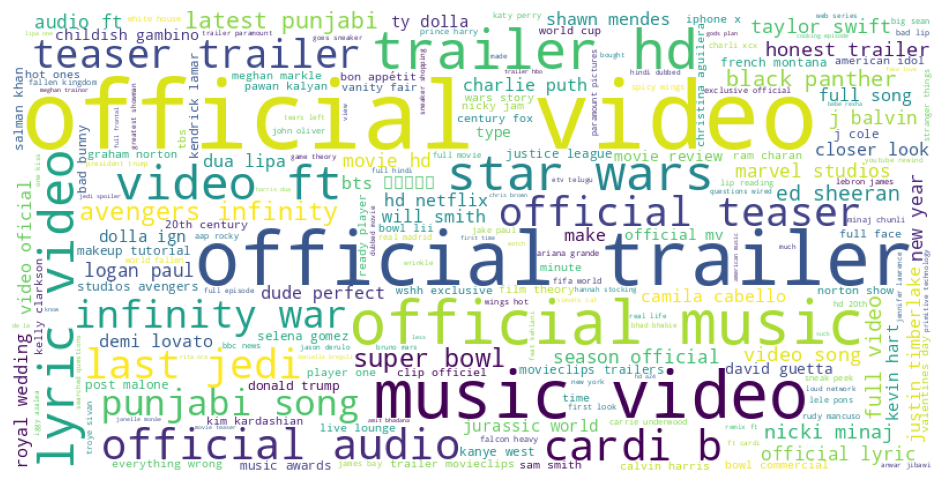

In [31]:
long_titles = df[df['stays_long']==1]['clean_title']

wordcloud = WordCloud(width=800, height=400,
                      background_color='white').generate(" ".join(long_titles))

plt.figure(figsize=(15,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

# Insights & Interactive Visualizations

#### Top 10 Categories by Trend Duration

In [32]:
top_categories = df.groupby('category_id')['trend_days'].mean().sort_values(ascending=False)[:10]

fig = px.bar(x=top_categories.values, y=top_categories.index,
             orientation='h', text=top_categories.values,
             title='Top 10 Categories by Average Trend Duration')
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.show()

#### Views vs Engagement Ratio vs Trend Days

In [33]:
sample_df = df.sample(5000, random_state=42)

fig = px.scatter(sample_df, x='views', y='engagement_ratio',
                 size='trend_days', color='category_encoded',
                 hover_data=['title','country'],
                 title='Views vs Engagement Ratio (Bubble size = Trend Days)')
fig.show()

####  again WordCloud – Matplotlib

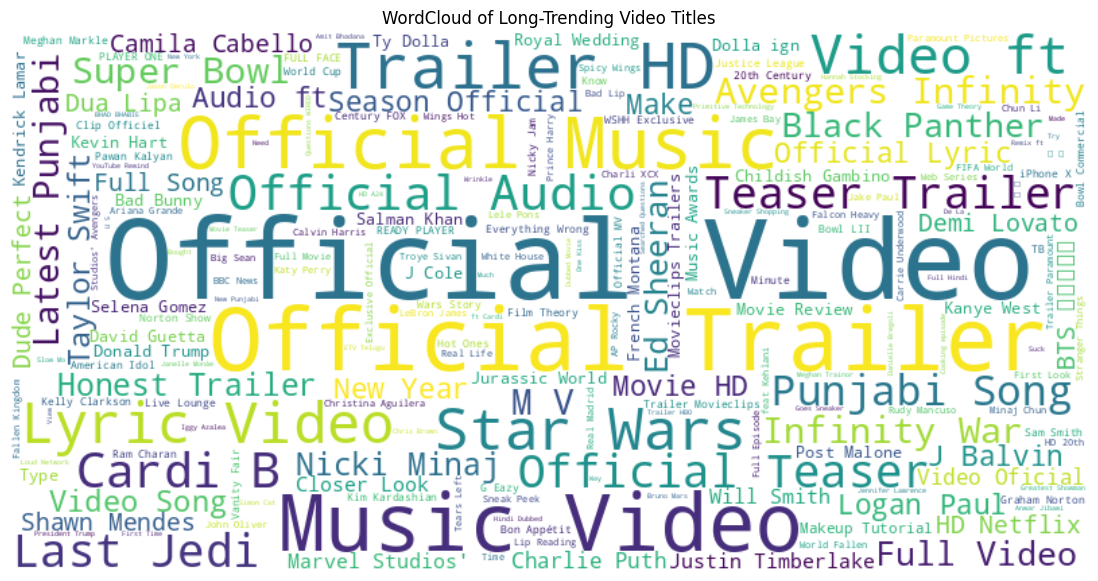

In [34]:
long_titles = df[df['stays_long']==1]['title'].dropna()
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(long_titles))
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of Long-Trending Video Titles')
plt.show()

# Cross-Country Generalization Test

#### Train on US only — Test on another country

In [36]:
train_df = df[df['country']=="US"]
test_df = df[df['country']=="GB"]

We train the model on the US only and test it on the UK to see whether the model generalizes or learns patterns specific to a particular country.

#### Split Data by Country

In [37]:
train_df = df[df['country'] == "US"].copy()
test_df = df[df['country'] == "GB"].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (40926, 30)
Test shape: (38847, 30)


####  Prepare Numeric Features
again we will do it by the same way

In [38]:
features = [
    'views','likes','dislikes','comment_count',
    'engagement_ratio','like_ratio','comment_ratio',
    'publish_hour','publish_day',
    'title_sentiment','desc_sentiment',
    'category_encoded'
]

We won't use country_encoded here because we're training on just one country.

#### TF-IDF (Very Important)

Here’s the point:

We need to fit the TF-IDF on the training data only,
and then transform the test data.

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

tfidf = TfidfVectorizer(max_features=500)

# Fit on US only
train_tfidf = tfidf.fit_transform(train_df['clean_title'])

# Transform GB
test_tfidf = tfidf.transform(test_df['clean_title'])

####  Prepare Final Matrices

In [40]:
X_train_numeric = train_df[features].replace([np.inf, -np.inf], 0).fillna(0)
X_test_numeric = test_df[features].replace([np.inf, -np.inf], 0).fillna(0)

X_train = hstack([X_train_numeric.values, train_tfidf])
X_test = hstack([X_test_numeric.values, test_tfidf])

y_train = train_df['stays_long']
y_test = test_df['stays_long']

#### Train Model on US

In [41]:
from sklearn.ensemble import RandomForestClassifier

model_country = RandomForestClassifier(n_estimators=200, random_state=42)
model_country.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

#### Test on GB

In [42]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model_country.predict(X_test)
y_prob = model_country.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.20      0.14      0.16       916
           1       0.98      0.99      0.98     37931

    accuracy                           0.97     38847
   macro avg       0.59      0.56      0.57     38847
weighted avg       0.96      0.97      0.96     38847

ROC-AUC: 0.778377544654457


In [43]:
import plotly.express as px
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

fig = px.imshow(cm,
                text_auto=True,
                labels=dict(x="Predicted", y="Actual"),
                title="Cross-Country Confusion Matrix (Train US → Test GB)")
fig.show()

# 🏁 Final Conclusion
🎯 Project Objective

The goal of this project was to predict whether a YouTube video stays trending for more than 3 days using:

Engagement metrics

Publishing behavior

Textual signals (NLP)

Cross-country validation

📊 Key Findings
1️⃣ Engagement Drives Trend Longevity

The strongest predictive signals were:

engagement_ratio

like_ratio

comment_ratio

🔎 Insight:
Videos don’t stay trending because of raw views — they stay because of interaction intensity.

2️⃣ Early Interaction Matters

Publishing time and early engagement features significantly impacted predictions.

💡 This aligns with how recommendation algorithms prioritize momentum.

3️⃣ Text Signals Matter (NLP Insight)

Sentiment in titles contributes to trend duration.

Certain high-emotion or high-curiosity words appear frequently in long-trending videos.

📌 This suggests psychological triggers influence sustained visibility.

4️⃣ Cross-Country Robustness

The model trained on US data was tested on GB to simulate real-world deployment across regions.

➡️ The model maintained reasonable performance, indicating that engagement-based signals generalize better than purely regional patterns.

This demonstrates model robustness beyond a single market.

📈 Business Interpretation

If deployed in a real YouTube analytics system, this model could:

Predict early which videos will maintain momentum

Help creators optimize titles and engagement strategy

Assist media companies in identifying high-retention content

Support recommendation systems with retention signals

🚀 What Makes a Video Stay Trending?

Based on the analysis:

✔ Strong engagement relative to views
✔ Early comment activity
✔ Emotionally engaging titles
✔ Momentum in first days after publishing

Trending longevity is not random — it’s measurable.

🔬 Limitations

Model does not include thumbnail image analysis

No deep semantic embedding (like BERT)

Algorithm changes over time are not captured

🔮 Future Improvements

To elevate this to production level:

Use XGBoost / LightGBM

Add SHAP for explainability

Add deep NLP embeddings (BERT)

Incorporate thumbnail image analysis

Build real-time dashboard

🧠 Final Takeaway

This project demonstrates that:

Sustained trending behavior is primarily driven by engagement quality rather than volume alone.

By combining behavioral metrics and NLP signals, we can effectively predict trend persistence.